In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Problem 4
### a)

In [39]:
states = [(3,0,0), (0,3,0), (0,0,3), (2,1,0), (2,0,1), (1,2,0), (1,0,2), (0,2,1), (0,1,2), (1,1,1)]

a = [0] * (len(states))
a[0] = 1

Q = np.array([[-1.4, 0, 0, 1.4, 0, 0, 0, 0, 0, 0],
  [0, -1.4, 0, 0, 0, 0, 0, 1.4, 0, 0],
  [0, 0, -1.4, 0, 0, 0, 1.4, 0, 0, 0],
  [0, 0, 0, -2.2, 1.4, 0.8, 0, 0, 0, 0],
  [0.3, 0, 0, 0, -1.7, 0, 0, 0, 0, 1.4],
  [0, 0.3, 0, 0, 0, -1.7, 0, 0, 0, 1.4],
  [0, 0, 0, 0, 0.8, 0, -2.2, 0, 1.4, 0],
  [0, 0, 0, 0, 0, 1.4, 0, -2.2, 0.8, 0],
  [0, 0, 0.3, 0, 0, 0, 0, 0, -1.7, 1.4],
  [0, 0, 0, 0.8, 0, 0, 0.8, 0.8, 0, -2.4]])

P = np.zeros(Q.shape)
for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        if i != j:
            P[i, j] = Q[i, j] / -Q[i, i]
        else:
            P[i, j] = 0

def sample_path(Q, a, T):
    P = np.zeros(Q.shape)
    for i in range(P.shape[0]):
        for j in range(P.shape[1]):
            if i != j:
                P[i, j] = Q[i, j] / -Q[i, i]
            else:
                P[i, j] = 0


    path = [a.index(1)]
    jump_rates = []
    holding_times = []

    while sum(holding_times) < T:
        jump_rates.append(float(-Q[path[-1], path[-1]]))
        holding_times.append(np.random.exponential(1 / jump_rates[-1]))
        path.append(np.random.choice(range(len(states)), p=P[path[-1]]))

    return path[:-1], jump_rates[:-1], holding_times[:-1] # discard the last jump and holding time since they exceed T

### b)
The total jump rate is calculated by the negative (positive value) of the diagonal entries of the Q matrix, depending on which state you're in. \
The holding time is generated by taking a random exponential sample using a parameter of the jump rate. \
The next transition is selected by constructing the P matrix and sampling from the probabilities of the corresponding row in it. \

### c)

In [40]:
MC_runs = 1000
results = {t: [] for t in np.arange(0.05, 5.01, 0.05)}
for t in np.arange(0.05, 5.01, 0.05):
    for _ in range(MC_runs):
        path, jump_rates, holding_times = sample_path(Q, a, t)
        #print(f"Time: {t:.2f}, Path: {[states[i] for i in path]}, Jump Rates: {jump_rates}, Holding Times: {holding_times}")
        results[t].append(states[path[-1]][0])

### d)

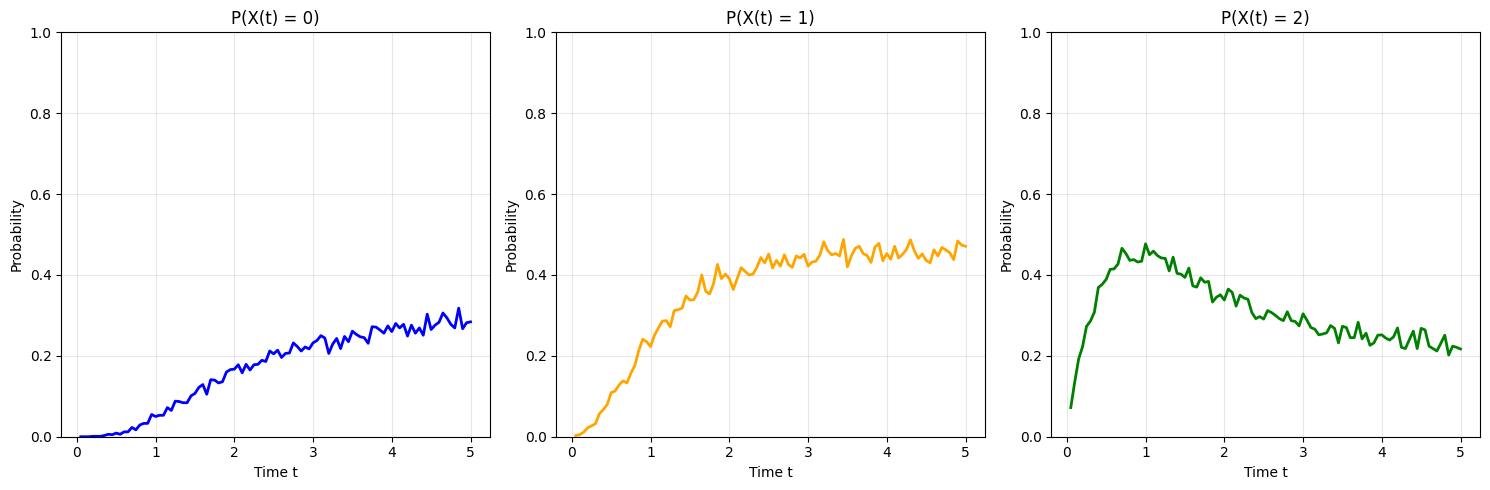

In [41]:
# Calculate probabilities for each state at each time
times = np.arange(0.05, 5.01, 0.05)
prob_state_0 = []
prob_state_1 = []
prob_state_2 = []

for t in times:
    prob_state_0.append(results[t].count(0) / MC_runs)
    prob_state_1.append(results[t].count(1) / MC_runs)
    prob_state_2.append(results[t].count(2) / MC_runs)

# OPTION 1: Line plots (cleaner, easier to read trends)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Subplot 1: State 0
axes[0].plot(times, prob_state_0, linewidth=2, color='blue')
axes[0].set_xlabel('Time t')
axes[0].set_ylabel('Probability')
axes[0].set_title('P(X(t) = 0)')
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# Subplot 2: State 1
axes[1].plot(times, prob_state_1, linewidth=2, color='orange')
axes[1].set_xlabel('Time t')
axes[1].set_ylabel('Probability')
axes[1].set_title('P(X(t) = 1)')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

# Subplot 3: State 2
axes[2].plot(times, prob_state_2, linewidth=2, color='green')
axes[2].set_xlabel('Time t')
axes[2].set_ylabel('Probability')
axes[2].set_title('P(X(t) = 2)')
axes[2].set_ylim(0, 1)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Problem 5
### a), b)

In [71]:
Q_A = np.array([[-1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
  [0, -1, 0, 0, 0, 0, 0, 1, 0, 0],
  [0, 0, -1, 0, 0, 0, 1, 0, 0, 0],
  [0, 0, 0, -2, 1, 1, 0, 0, 0, 0],
  [1, 0, 0, 0, -2, 0, 0, 0, 0, 1],
  [0, 1, 0, 0, 0, -2, 0, 0, 0, 1],
  [0, 0, 0, 0, 1, 0, -2, 0, 1, 0],
  [0, 0, 0, 0, 0, 1, 0, -2, 1, 0],
  [0, 0, 1, 0, 0, 0, 0, 0, -2, 1],
  [0, 0, 0, 1, 0, 0, 1, 1, 0, -3]])

Q_A_copy = Q_A.T.copy()
Q_A_copy[-1, :] = np.ones(Q_A_copy.shape[1])  # Replace last row with ones for normalization
b = np.zeros(Q_A_copy.shape[0])
b[-1] = 1  # Set last element to 1 for normalization
pi_A = np.linalg.solve(Q_A_copy, b)  # Solve for stationary distribution
print("Stationary distribution for Q_A: ", pi_A)


Q_B = np.array([[-1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
  [0, -1, 0, 0, 0, 0, 0, 1, 0, 0],
  [0, 0, -1, 0, 0, 0, 1, 0, 0, 0],
  [0, 0, 0, -2, 1, 1, 0, 0, 0, 0],
  [0.4, 0, 0, 0, -1.4, 0, 0, 0, 0, 1],
  [0, 1, 0, 0, 0, -2, 0, 0, 0, 1],
  [0, 0, 0, 0, 1, 0, -2, 0, 1, 0],
  [0, 0, 0, 0, 0, 1, 0, -2, 1, 0],
  [0, 0, 1, 0, 0, 0, 0, 0, -2, 1],
  [0, 0, 0, 1, 0, 0, 1, 1, 0, -3]])

Q_B_copy = Q_B.T.copy()
Q_B_copy[-1, :] = np.ones(Q_B_copy.shape[1])  # Replace last row with ones for normalization
b = np.zeros(Q_B_copy.shape[0])
b[-1] = 1  # Set last element to 1 for normalization
pi_B = np.linalg.solve(Q_B_copy, b)  # Solve for stationary distribution
print("Stationary distribution for Q_B: ", pi_B)

Stationary distribution for Q_A:  [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Stationary distribution for Q_B:  [0.05514316 0.09331919 0.10604454 0.08377519 0.1378579  0.09331919
 0.10922587 0.1028632  0.10604454 0.11240721]


### c)

In [80]:
expected_cost = [3*states[i][0] if states[i][0] >= 2 else 0 for i in range(len(states))]
for i in range(len(states)):
    expected_cost[i] += 1 * states[i][1]
print("Policy A stationary expected cost for each state: ", sum(expected_cost * pi_A))
print("Policy B stationary expected cost for each state: ", sum(expected_cost * pi_B))

Policy A stationary expected cost for each state:  3.0999999999999996
Policy B stationary expected cost for each state:  2.800636267232238


### d)

In [87]:
T = 2000
long_run_path_A, _, long_run_wait_times_A = sample_path(Q_A, a, T)
long_run_path_B, _, long_run_wait_times_B = sample_path(Q_B, a, T)

long_run_avg_cost_A = sum([expected_cost[long_run_path_A[i]] * long_run_wait_times_A[i] for i in range(len(long_run_path_A)-1)]) / T
long_run_avg_cost_B = sum([expected_cost[long_run_path_B[i]] * long_run_wait_times_B[i] for i in range(len(long_run_path_B)-1)]) / T
print("Long-run average cost for Policy A: ", long_run_avg_cost_A)
print("Long-run average cost for Policy B: ", long_run_avg_cost_B)

Long-run average cost for Policy A:  3.061993075038311
Long-run average cost for Policy B:  2.714075738244462


### e)
The analytical and simulation results are relatively close, with policy A being slightly closer in both absolute and relative value. 

### f)
Under this cost function, policy B is better. 

### g)
The only difference between the two policies is that one rate to A is faster if it is crowded.